In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">09_wine품질등급예측(다중분류)</font></b>

In [20]:
import numpy as np
import pandas as pd # get_dummies, 원핫인코딩
from tensorflow.keras.datasets import mnist # mnist 데이터셋
from tensorflow.keras import utils
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model # 모델생성
from tensorflow.keras.layers import Input, Dense, Dropout
import matplotlib.pyplot as plt # 학습과정 loss와 acc 시각화

# quiz에서는 scale조정, train_test_split 등을 추가

from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 스케일조정
from sklearn.model_selection import train_test_split # 데이터 분리

# callback함수들 load ( Callback, EarlyStopping, ModelCheckpoint )
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
import os

- Red Wine 등급 예측
1. 데이터 셋 확보
    csv -> 결측치처리 -> 독립변수와 타겟변수 분리 -> 독립변수 스케일조정,
    -> 타겟변수의 원핫인코딩 -> 훈련셋과 테스트셋분리(train_test_split이용 층화추출)
2. 모델 구성(입력11, 출력6-pd.getdummies | 출력9-to_categorical)
3. 모델 학습 과정 설정
4. 모델 학습(callbacks이용)
5. 모델 평가(그래프, 평가, 교차표)
6. 모델 저장 & 사용

# 1. 데이터 확보 & 전처리

In [5]:
# fixed acidity : 고정 산도
# volatile acidity : 휘발성 산도
# citric acid : 시트르산
# residual sugar : 잔류 당분
# chlorides : 염화물
# free sulfur dioxide : 자유 이산화황
# total sulfur dioxide : 총 이산화황
# density : 밀도
# pH
# sulphates : 황산염
# alcohol
# quality : 0 ~ 10(높을 수록 좋은 품질)

In [6]:
# 데이터 읽어오기
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine.info() # 결측치확인(없음)
redwine['quality'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64

In [8]:
redwine.values

array([[ 7.4  ,  0.7  ,  0.   , ...,  0.56 ,  9.4  ,  5.   ],
       [ 7.8  ,  0.88 ,  0.   , ...,  0.68 ,  9.8  ,  5.   ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  0.65 ,  9.8  ,  5.   ],
       ...,
       [ 6.3  ,  0.51 ,  0.13 , ...,  0.75 , 11.   ,  6.   ],
       [ 5.9  ,  0.645,  0.12 , ...,  0.71 , 10.2  ,  5.   ],
       [ 6.   ,  0.31 ,  0.47 , ...,  0.66 , 11.   ,  6.   ]])

# 1. 데이터 확보 & 전처리 선생님ver

In [21]:
# 데이터 읽어오기
# fixed acidity : 고정 산도
# volatile acidity : 휘발성 산도
# citric acid : 시트르산
# residual sugar : 잔류 당분
# chlorides : 염화물
# free sulfur dioxide : 자유 이산화황
# total sulfur dioxide : 총 이산화황
# density : 밀도
# pH
# sulphates : 황산염
# alcohol
# quality : 0 ~ 10(높을 수록 좋은 품질)
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
# 결측치 확인
print('결측치 확인\n',redwine.isna().sum())
# 독립변수와 타겟변수 분리
redwine_X = redwine.iloc[:,:-1].to_numpy() # .values와 유사
redwine_y = redwine.iloc[:,-1]
print('타겟변수가 될 와인 등급 종류 : ', redwine_y.unique()) # 3,4,5,6,7,8 
print('등급별 데이터 수 :\n', redwine_y.value_counts()) # 3과 8은 데이터 수가 적어 못 맞출 듯

# 독립변수 scale 조정
scaler = StandardScaler()
scaler.fit(redwine_X)
scaled_X_redwine = scaler.transform(redwine_X)

# 타겟변수 원핫인코딩 후 numpy 배열로 변환
Y_redwine = pd.get_dummies(redwine_y).values # to_numpy()와 유사
Y_redwine

# 훈련셋과 테스트셋 분리 (7:3)
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X_redwine,
                                                   Y_redwine,
                                                   test_size=0.3, # 테스트셋비율
                                                   random_state=7,
                                                   stratify=Y_redwine) # 층화추출                                                   
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

결측치 확인
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
타겟변수가 될 와인 등급 종류 :  [5 6 7 4 8 3]
등급별 데이터 수 :
 5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64
(1119, 11) (1119, 6) (480, 11) (480, 6)


In [22]:
# 층화추출을 하면 등급별 7:3으로  shuffle 되서 추출
print('train, test, all')
print(
np.c_[pd.Series(Y_train.argmax(axis=1)).value_counts(),
      pd.Series(Y_test.argmax(axis=1)).value_counts(),
     redwine_y.value_counts()]
)

train, test, all
[[477 204 681]
 [446 192 638]
 [139  60 199]
 [ 37  16  53]
 [ 13   5  18]
 [  7   3  10]]


# 2. 모델 구성(입력11, 출력6) layer층 4

In [23]:
# 2. 모델 구성하기
model = Sequential()
model.add(Input(shape=(11,))) # 의미있는 레이어가 아니고 input_dim만 지정
model.add(Dense(units=64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=30, activation="relu"))
model.add(Dense(units=6, activation="softmax")) # 3 4 5 6 7 8 등급의 결과 합이 1
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                768       
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 30)                1950      
                                                                 
 dense_8 (Dense)             (None, 6)                 186       
                                                                 
Total params: 2,904
Trainable params: 2,904
Non-trainable params: 0
_________________________________________________________________


# 3. 모델 학습 과정 설정

In [24]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

# 4. 모델학습(callbacks이용)

In [25]:
%%time

class CustomHistory(Callback): # on_epoch_end()는 각 에포크 종료시 자동 호출
    def __init__(self): # 생성자 함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        self.epoch += 1
        if self.epoch%5 ==0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                 format(self.epoch, 
                        logs.get('loss'), 
                        logs.get('accuracy'),
                        logs.get('val_loss'),
                        logs.get('val_accuracy')
                       ))
model_save_folder = './model/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'wine-{epoch:03d}-val{val_accuracy:.4f}.h5'
# 모델 자동저장 콜백
checkpoint = ModelCheckpoint(filepath=file,          # 저장경로
                             monitor='val_accuracy', # 모니터링할 지표 'loss', 'accuracy', 'val_loss' 등
                            save_best_only=True,     # 모니터링 지표가 개선된 경우만 저장. False로 하면 매번 에포크마다 저장
                            mode='max',         # 값이 클수록 좋을 때, 'min'은 값이 작을수록 좋을 때. auto도 있음
                            verbose=1)            # 저장 시 로그 출력 (1: 저장시 메세지 출력, 0: 출력 안 함)
customHistory = CustomHistory()
earlyStropping = EarlyStopping(patience=20)
hist = model.fit(X_train, Y_train, epochs=200, batch_size=200, 
                 validation_split=0.2, 
                 callbacks=[earlyStropping, 
                           customHistory,
                           checkpoint],
                verbose=0)


Epoch 1: val_accuracy improved from -inf to 0.29911, saving model to ./model\wine-001-val0.2991.h5

Epoch 2: val_accuracy improved from 0.29911 to 0.42857, saving model to ./model\wine-002-val0.4286.h5

Epoch 3: val_accuracy improved from 0.42857 to 0.43750, saving model to ./model\wine-003-val0.4375.h5

Epoch 4: val_accuracy improved from 0.43750 to 0.44643, saving model to ./model\wine-004-val0.4464.h5
epoch:5, loss:1.4090778827667236, acc:0.49832403659820557, val_loss:1.4028059244155884, val_acc:0.4776785671710968

Epoch 5: val_accuracy improved from 0.44643 to 0.47768, saving model to ./model\wine-005-val0.4777.h5

Epoch 6: val_accuracy improved from 0.47768 to 0.48661, saving model to ./model\wine-006-val0.4866.h5

Epoch 7: val_accuracy improved from 0.48661 to 0.51786, saving model to ./model\wine-007-val0.5179.h5

Epoch 8: val_accuracy did not improve from 0.51786

Epoch 9: val_accuracy did not improve from 0.51786
epoch:10, loss:1.160056710243225, acc:0.5374301671981812, val_l

# 5. 모델 평가 - 그래프, 평가(테스트셋), 교차표(crosstab)

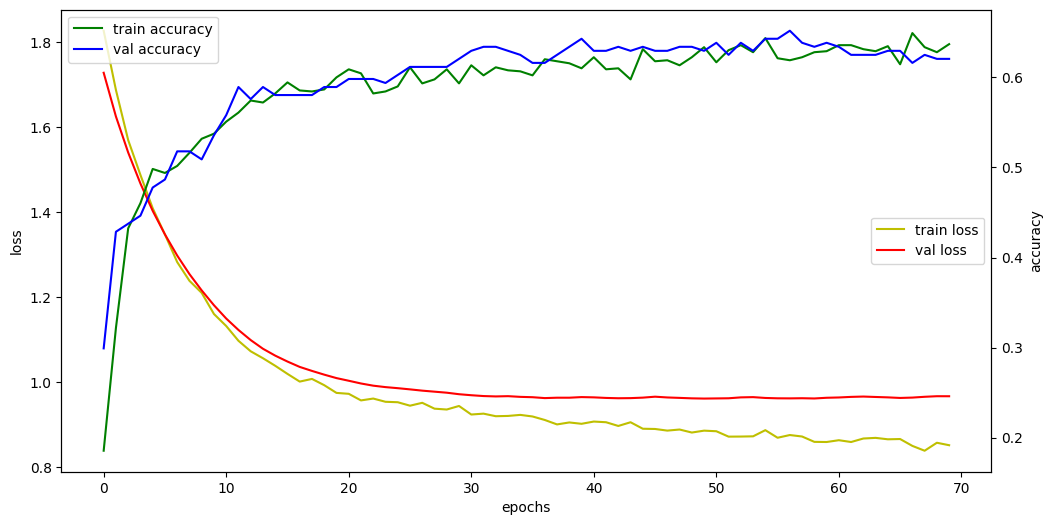

In [27]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [31]:
# 어떤 모델을 쓸지?
loss_and_acc = model.evaluate(X_test, Y_test, batch_size=32, verbose=0)
print('현 모델의 loss : ', loss_and_acc[0])
print('현 모델의 accuracy : ', loss_and_acc[1])
model2 = load_model('model/wine-057-val0.6518.h5')
loss_and_acc2 = model2.evaluate(X_test, Y_test, batch_size=32, verbose=0)
print('저장된 모델 중 best모델 loss : ', loss_and_acc2[0])
print('저장된 모델 중 best모델 accuracy : ', loss_and_acc2[1])

현 모델의 loss :  1.0230660438537598
현 모델의 accuracy :  0.612500011920929
저장된 모델 중 best모델 loss :  1.0276401042938232
저장된 모델 중 best모델 accuracy :  0.6020833253860474


In [32]:
# 성능 지표(crosstab)
# Y_test : 0 0 1 0 0 0 (3등급, 4등급, 5등급, 6등급, 7등급, 8등급)
y = np.argmax(Y_test, axis=1) +3 # Y_test의 실제값(pd.getdummies)
yhat = model2.predict(X_test).argmax(axis=1)+3 # 예측값
pd.crosstab(y, yhat, rownames=['real'], colnames=['predict'])

15/15 [==============================] - 0s 2ms/step


predict,4,5,6,7
real,,,,
3,1,2,0,0
4,0,9,7,0
5,1,158,43,2
6,0,64,104,24
7,0,8,25,27
8,0,0,4,1


# 6. 모델 사용하기

In [33]:
# 6. 모델 사용하기
input_data = np.array([7.4,0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4])
scaled_data = scaler.transform(input_data.reshape(1,11))
print(np.argmax(model.predict(scaled_data), axis=1) + 3, '등급으로 예측함')

1/1 [==============================] - 0s 30ms/step
[5] 등급으로 예측함
